**TESTING MODERN PORTFOLIO THEORY ON GOLDMAN SACHS, CRISIL, HDFC BANK, MORGAN STANLEY CAPITAL INDEX, VISA**

In [2]:
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

** DOWNLOADING DATA USING YFINANCE**

In [3]:
tickers = ['GS', 'MSCI', 'V', 'CRISIL.NS', 'HDFCBANK.NS']
data = yf.download(tickers, start='2019-01-01', end='2026-01-01')['Close']
print(data.shape)
print(data.head())

/tmp/ipykernel_1445/785333385.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='2019-01-01', end='2026-01-01')['Close']
[*********************100%***********************]  5 of 5 completed

(1816, 5)
Ticker        CRISIL.NS          GS  HDFCBANK.NS        MSCI           V
Date                                                                    
2019-01-01  1433.922729         NaN   496.185852         NaN         NaN
2019-01-02  1438.881470  144.753693   491.658508  135.801666  126.068077
2019-01-03  1450.391968  142.633270   487.800995  130.626129  121.525017
2019-01-04  1440.121094  147.294891   489.106049  135.487366  126.760437
2019-01-07  1451.986206  148.111053   489.845154  136.115845  129.046249


In [4]:
print(data.isna().sum())
print(data.isna().sum().sum())

Ticker
CRISIL.NS      86
GS             56
HDFCBANK.NS    86
MSCI           56
V              56
dtype: int64
340


In [5]:
data_clean = data.dropna()
print(data_clean.shape)
print(data_clean.isna().sum().sum())

(1674, 5)
0


In [6]:
returns = data_clean.pct_change(fill_method=None).dropna()
returns.shape

(1673, 5)

**COVARIANCE MATRIX**

In [7]:
cov_matrix = returns.cov()
cov_matrix

Ticker,CRISIL.NS,GS,HDFCBANK.NS,MSCI,V
Ticker,,,,,
CRISIL.NS,0.000452,0.000034,0.000056,0.000037,0.000027
GS,0.000034,0.000418,0.000070,0.000205,0.000193
HDFCBANK.NS,0.000056,0.000070,0.000257,0.000047,0.000060
MSCI,0.000037,0.000205,0.000047,0.000463,0.000204
V,0.000027,0.000193,0.000060,0.000204,0.000272


**CORRELATION MATRIX**

In [8]:
corr_matrix = returns.corr()
corr_matrix

Ticker,CRISIL.NS,GS,HDFCBANK.NS,MSCI,V
Ticker,,,,,
CRISIL.NS,1.000000,0.077564,0.165054,0.080848,0.078261
GS,0.077564,1.000000,0.213199,0.466451,0.574016
HDFCBANK.NS,0.165054,0.213199,1.000000,0.135153,0.226517
MSCI,0.080848,0.466451,0.135153,1.000000,0.575410
V,0.078261,0.574016,0.226517,0.575410,1.000000


**HEATMAP**

/tmp/ipykernel_1445/1504125284.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


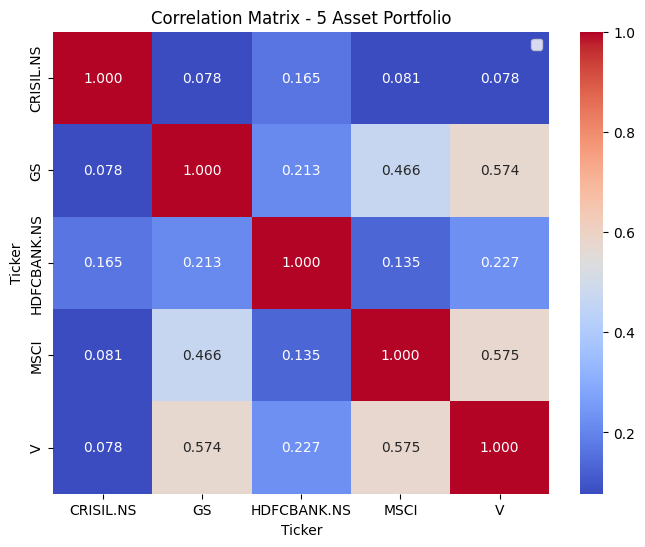

In [9]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,annot=True,fmt="0.3f",cmap='coolwarm')
plt.title("Correlation Matrix - 5 Asset Portfolio")
plt.legend()
plt.show()

**MARKOWITZ OPTIMIZATION**

In [10]:
means_return = returns.mean()
print(f"Mean of daily returns is:\n {means_return}")

Mean of daily returns is:
 Ticker
CRISIL.NS      0.000875
GS             0.001281
HDFCBANK.NS    0.000538
MSCI           0.001089
V              0.000745
dtype: float64


In [11]:
weights = np.array([0.2,0.2,0.2,0.2,0.2]) #starting off with equal weights

In [12]:
portfolio_return = np.dot(weights,means_return)
print(f"The portfolio return is: {round(portfolio_return,4)}")

The portfolio return is: 0.0009


In [13]:
portfolio_variance = np.dot(weights.T,np.dot(cov_matrix,weights))
print(f"The portfolio variance is: {round(portfolio_variance,4)}")

The portfolio variance is: 0.0001


In [14]:
portoflio_standard_deviation = np.sqrt(portfolio_variance)
print(f"The portfolio standard deviation is: {round(portoflio_standard_deviation,4)}")

The portfolio standard deviation is: 0.0122


In [15]:
from scipy.optimize import minimize

def portfolio_variance(weights, cov_matrix):
    return np.dot(weights.T, np.dot(cov_matrix, weights))

num_assets = 5
constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
bounds = tuple((0, 1) for _ in range(num_assets))
initial_guess = num_assets * [1./num_assets]

result = minimize(portfolio_variance, initial_guess, args=(cov_matrix,),
                   method='SLSQP', bounds=bounds, constraints=constraints)

min_var_weights = result.x
print(min_var_weights)
print(portfolio_variance(min_var_weights, cov_matrix))

[0.2 0.2 0.2 0.2 0.2]
0.00014913158553883115


In [16]:
result = minimize(portfolio_variance, initial_guess, args=(cov_matrix,),
                   method='SLSQP', bounds=bounds, constraints=constraints,
                   tol=1e-12)

min_var_weights = result.x
print(result.x)

[0.21558416 0.07116936 0.36592444 0.07790997 0.26941207]


In [17]:
target_returns = np.linspace(means_return.min(), means_return.max(), 50)
frontier_variances = []

for T in target_returns:
    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w, T=T: np.dot(w,means_return) - T}
    )
    result = minimize(portfolio_variance, initial_guess, args=(cov_matrix,),
                       method='SLSQP', bounds=bounds, constraints=constraints, tol=1e-12)
    frontier_variances.append(result.fun)

frontier_std = np.sqrt(frontier_variances)

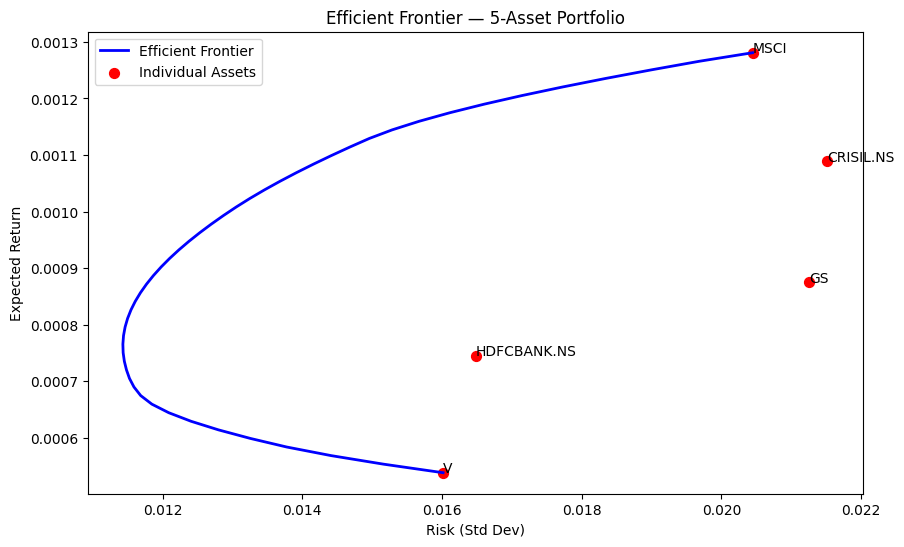

In [19]:
plt.figure(figsize=(10,6))
plt.plot(frontier_std, target_returns,'b-',  linewidth=2, label='Efficient Frontier')
plt.scatter(np.sqrt(np.diag(cov_matrix)), means_return, color='red', s=50, label='Individual Assets')
for i, ticker in enumerate(tickers):
    plt.annotate(ticker, (np.sqrt(cov_matrix.iloc[i,i]), means_return.iloc[i]))
plt.xlabel('Risk (Std Dev)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier — 5-Asset Portfolio')
plt.legend()
plt.show()